# Hackaton 2024 - 2025

## Les Koalas d'Australie vous présentent leur projet de prédictions de catastrophes naturelles à Toulouse en 2180

## Notre équipe
- ROELENS Jean (Chef d'équipe)
- ANDRAWS Pascal
- GUELL Marine
- GUESMI Isra
- LAMBERT Louis
- MAIMOUNI Mouhcine
- RIGAL Nino

## Contexte
En 2180, la mégapole qu'est devenue Toulouse est sujette à de violentes catastrophe naturelles qui détruisent la ville. Heureusement un groupe de jeunes experts se sont ligués pour protégé la ville rose des inondations, tremblements de terre, hackers et autres cataclysmes. Chaque unité à sa manière a pu mettre en place une solution IT pour couvrir l'ensemble des menaces possibles.

Nous sommes les koalas d'Australie, un groupe spécialisé en Data science et nous avons choisi de créer un modèle servant à prédire les inondations et les tremblements de terres qui secouent les Toulousains.

Bienvenue dans notre projet

D'autres équipes Toulousaines nous ont fournie des données, mais ils nous ont aussi informés qu'il fallait apporter quelques modifications avant de pouvoir les utiliser.

In [141]:
import pandas as pd
from pprint import pprint
import csv

In [142]:
# Chemin vers le fichier CSV
input_file = "catastrophes_naturelles(1).csv"
output_file = "clean_catastrophes_naturelles(1).csv"

def initial_cleaning(chemin_fichier, chemin_sortie):
    try:
        # Ouvrir et lire le fichier d'entrée
        with open(chemin_fichier, 'r', encoding='utf-8') as fichier:
            contenu = fichier.read()

        # Supprimer les guillemets
        clean_contenu = contenu.replace('"', '')

        clean_contenu = clean_contenu.replace('aucun', '0')
        clean_contenu = clean_contenu.replace("['seisme']", '1')
        clean_contenu = clean_contenu.replace("['innondation']", '2')
        clean_contenu = clean_contenu.replace("['innondation', 'seisme']", '3')

        clean_contenu = clean_contenu.replace("Zone 1", '1')
        clean_contenu = clean_contenu.replace("Zone 2", '3')
        clean_contenu = clean_contenu.replace("Zone 3", '4')
        clean_contenu = clean_contenu.replace("Zone 4", '2')
        clean_contenu = clean_contenu.replace("Zone 5", '5')

        # Sauvegarder le contenu modifié dans un nouveau fichier
        with open(chemin_sortie, 'w', encoding='utf-8') as fichier_sortie:
            fichier_sortie.write(clean_contenu)

        print(f"Le fichier modifié est enregistré dans : {chemin_sortie}")

    except FileNotFoundError:
        print("Le fichier spécifié est introuvable.")
    except Exception as e:
        print(f"Une erreur est survenue : {e}")

# Appel de la fonction
initial_cleaning(input_file, output_file)

Le fichier modifié est enregistré dans : clean_catastrophes_naturelles(1).csv


Le fichier est prêt pour commencer. Notre première étape consiste à se familiariser avec les données, pour ça nous allons utiliser plusieurs indicateurs.

## Les 5 premières lignes du dataset

In [143]:
# Attempt to read the file with a specific encoding
def get_data(file):
    try:
        data = pd.read_csv(file,encoding='latin-1', sep=',')
        pprint("Aperçu des 5 premières lignes du dataset :")
        pprint(data.head())
    except UnicodeDecodeError as e:
        pprint(f"UnicodeDecodeError: {e}")
    except FileNotFoundError as e:
        pprint(f"FileNotFoundError raised with : {e}")
    return data

data = get_data(output_file)

'Aperçu des 5 premières lignes du dataset :'
   Unnamed: 0  temperature  humidite  force_moyenne_du_vecteur_de_vent  \
0           0          5.7      75.6                               3.8   
1           1          5.7      75.6                               3.8   
2           2          5.7      75.6                               3.8   
3           3          5.7      75.6                               3.8   
4           4          5.7      75.6                               3.8   

   force_du_vecteur_de_vent_max  pluie_intensite_max        date  quartier  \
0                           4.3                  0.0  2170-01-01         1   
1                           4.3                  0.0  2170-01-01         3   
2                           4.3                  0.0  2170-01-01         4   
3                           4.3                  0.0  2170-01-01         2   
4                           4.3                  0.0  2170-01-01         5   

   sismicite  concentration_gaz  pluie_to

## Shape

In [144]:
data.shape

(3395, 12)

## Features

In [145]:
data.columns

Index(['Unnamed: 0', 'temperature', 'humidite',
       'force_moyenne_du_vecteur_de_vent', 'force_du_vecteur_de_vent_max',
       'pluie_intensite_max', 'date', 'quartier', 'sismicite',
       'concentration_gaz', 'pluie_totale', 'catastrophe'],
      dtype='object')

## Dtypes per features

In [146]:
data.dtypes

Unnamed: 0                            int64
temperature                         float64
humidite                            float64
force_moyenne_du_vecteur_de_vent    float64
force_du_vecteur_de_vent_max        float64
pluie_intensite_max                 float64
date                                 object
quartier                              int64
sismicite                           float64
concentration_gaz                   float64
pluie_totale                        float64
catastrophe                           int64
dtype: object

## Vue globale

In [147]:
data.describe()

,Unnamed: 0,temperature,humidite,force_moyenne_du_vecteur_de_vent,force_du_vecteur_de_vent_max,pluie_intensite_max,quartier,sismicite,concentration_gaz,pluie_totale,catastrophe
count,3395.000000,3395.000000,3395.000000,3395.000000,3395.000000,3395.000000,3395.000000,3395.000000,3395.000000,3395.000000,3395.000000
mean,1697.000000,23.101178,56.239175,5.796907,11.547275,0.008100,3.000000,0.648162,194.305184,462.217620,1.102209
std,980.196409,10.415629,13.473980,3.366256,7.004531,0.031777,1.414422,0.178118,53.029867,271.815926,1.011940
min,0.000000,-29.700000,13.400000,1.100000,0.000000,0.000000,1.000000,0.300000,100.080000,0.100000,0.000000
25%,848.500000,15.700000,46.700000,3.500000,6.900000,0.000000,2.000000,0.525000,155.320000,229.500000,0.000000
50%,1697.000000,21.300000,58.200000,4.700000,10.300000,0.000000,3.000000,0.640000,186.900000,457.730000,1.000000
75%,2545.500000,31.300000,66.500000,6.900000,14.600000,0.000000,4.000000,0.790000,236.815000,681.785000,2.000000
max,3394.000000,46.300000,84.700000,32.300000,57.600000,0.300000,5.000000,1.000000,299.900000,999.870000,3.000000


Le dernier visuel que l'on souhaite utiliser est la matrice de corrélation, mais pour ça il faut que l'on se débarasse de la date.

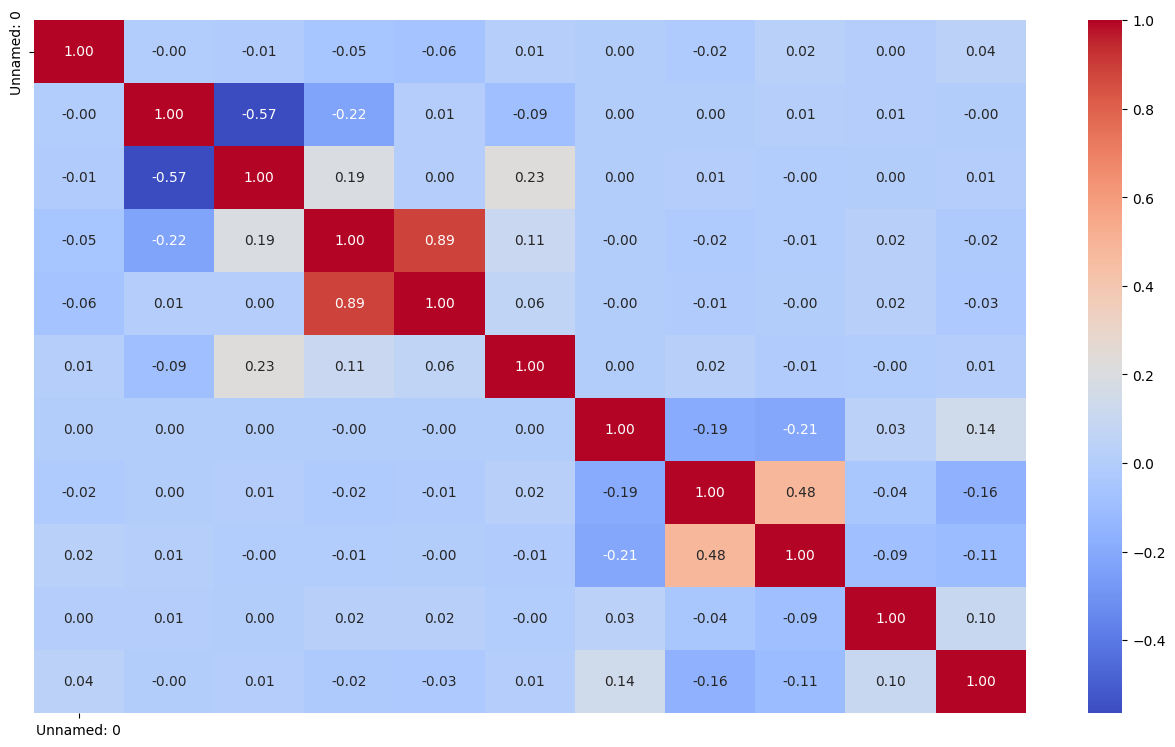

In [148]:
import matplotlib.pyplot as plt
import seaborn as sns

data = data.drop(columns=['date'])

plt.figure(figsize=(16,9))
sns.heatmap(data.corr(), cmap='coolwarm',annot=True, fmt=".2f", xticklabels=45, yticklabels=45)
plt.show()

Nos observations nous ont permit de mieux comprendre les données à notre disposition. Notre dataset est composé de 3995 lignes elles même composées de 12 colonnes. Notre objecifs étant de prédire la valeur de la dernière colonne cela signifie que nous avons donc 11 features à notre disposition pour tenter de prédire ces catastrophes. En effet, nous n'utiliserons pas la première colonne qui est juste l'identifiant de la ligne.

# Ajouter une phrase à propos de la matrice de corrélation

Les données qui nous sont fournies sont fournies pour nous entrainer sont complète, mais nous avons été prévenues par les groupes IOT en charge de leur récupération qu'elles ne serons pas toujours aussi fournies, nous prévoyons donc de nous séparer des colonnes qui ne pourront pas nous être fournies à l'avenir.

Commençons tout de même par utiliser toutes les données à notre disposition.

# Nos modèles

In [149]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder

Commençons par régénérer les données qui ont été modifié pendant la visualisation

In [150]:
data = get_data(output_file)

'Aperçu des 5 premières lignes du dataset :'
   Unnamed: 0  temperature  humidite  force_moyenne_du_vecteur_de_vent  \
0           0          5.7      75.6                               3.8   
1           1          5.7      75.6                               3.8   
2           2          5.7      75.6                               3.8   
3           3          5.7      75.6                               3.8   
4           4          5.7      75.6                               3.8   

   force_du_vecteur_de_vent_max  pluie_intensite_max        date  quartier  \
0                           4.3                  0.0  2170-01-01         1   
1                           4.3                  0.0  2170-01-01         3   
2                           4.3                  0.0  2170-01-01         4   
3                           4.3                  0.0  2170-01-01         2   
4                           4.3                  0.0  2170-01-01         5   

   sismicite  concentration_gaz  pluie_to

Supprimons les colonnes inutiles, la première colonne qui n'est que le numéro de la ligne et la date qui n'est pas utile, nous n'avons trouvé aucune saisonnalité et nos tests avec ou sans date donnent des scores similaires.

In [151]:
data = data.drop(columns=['date'])
data = data.drop(columns=['Unnamed: 0'])
data

,temperature,humidite,force_moyenne_du_vecteur_de_vent,force_du_vecteur_de_vent_max,pluie_intensite_max,quartier,sismicite,concentration_gaz,pluie_totale,catastrophe
0,5.7,75.6,3.8,4.3,0.0,1,0.62,231.56,182.37,0
1,5.7,75.6,3.8,4.3,0.0,3,0.94,248.20,903.20,1
2,5.7,75.6,3.8,4.3,0.0,4,0.95,240.55,363.06,1
3,5.7,75.6,3.8,4.3,0.0,2,0.39,159.10,473.93,0
4,5.7,75.6,3.8,4.3,0.0,5,0.41,143.29,475.72,2
...,...,...,...,...,...,...,...,...,...,...
3390,27.4,46.8,3.8,6.3,0.0,1,0.86,184.18,63.64,0
3391,27.4,46.8,3.8,6.3,0.0,3,0.74,227.11,874.81,3
3392,27.4,46.8,3.8,6.3,0.0,4,0.53,204.04,668.92,0
3393,27.4,46.8,3.8,6.3,0.0,2,0.42,182.63,660.69,2


# La normalisation
On normalise les colonnes mathématiques pour tenter d'améliorer les performances des modèles.

In [152]:
import numpy as np
from sklearn.preprocessing import OneHotEncoder

def normaliser(x):
    return (x-np.min(x))/(np.max(x)-np.min(x))

data_to_normalise =  data.drop(columns=['quartier', 'catastrophe'])
for feature in data_to_normalise:
    data[feature] = normaliser(data_to_normalise[feature])

data

,temperature,humidite,force_moyenne_du_vecteur_de_vent,force_du_vecteur_de_vent_max,pluie_intensite_max,quartier,sismicite,concentration_gaz,pluie_totale,catastrophe
0,0.465789,0.872370,0.086538,0.074653,0.0,1,0.457143,0.657992,0.182312,0
1,0.465789,0.872370,0.086538,0.074653,0.0,3,0.914286,0.741267,0.903308,1
2,0.465789,0.872370,0.086538,0.074653,0.0,4,0.928571,0.702983,0.363044,1
3,0.465789,0.872370,0.086538,0.074653,0.0,2,0.128571,0.295366,0.473939,0
4,0.465789,0.872370,0.086538,0.074653,0.0,5,0.157143,0.216245,0.475729,2
...,...,...,...,...,...,...,...,...,...,...
3390,0.751316,0.468443,0.086538,0.109375,0.0,1,0.800000,0.420879,0.063555,0
3391,0.751316,0.468443,0.086538,0.109375,0.0,3,0.628571,0.635722,0.874911,3
3392,0.751316,0.468443,0.086538,0.109375,0.0,4,0.328571,0.520268,0.668974,0
3393,0.751316,0.468443,0.086538,0.109375,0.0,2,0.171429,0.413122,0.660742,2


On sépare 5 lignes prises au "hasard", hasard fixé par une seed pour toujours choisir les mêmes

In [153]:
# Extraire les données de validation
validation_data = data.sample(n=5, random_state=42)  # Données de validation
data = data.drop(validation_data.index)  # Supprimer ces données du dataset

# Séparer les features (X) et la target (y)
y = data['catastrophe']
X = data.drop(columns=['catastrophe'])


On sépare le dataset en 2 parties:
- L'entrainement
- Le test

Nous avons choisi d'utiliser un ration 80/20 en faveur de l'entrainement, c'est le ratio standard pour cette séparation.

In [154]:
# Step 2 : Split data between train and test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## Grid Search
Nous allons maintenant utiliser Grid Search pour chercher la meilleures configuration d'hyperparamètre pour nos modèles. Nous avons choisi de tester deux objectifs pour GridSearch afin de garder le meilleur modèle, nous cherchons donc les meilleurs hyperparamètres pour maximiser d'abord la précision puis nous chercherons ceux pour maximiser le R² Score

In [156]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

# Définir la grille d'hyperparamètres
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [6, 7, 8],
    'min_samples_split': [2, 3, 4],
    'min_samples_leaf': [1, 2, 3],
    'bootstrap': [False, True],
    'class_weight': ['balanced', 'balanced_subsample', None]

}

# Configuration de la recherche par grille
grid_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid,
    scoring='accuracy',
    cv=4,
    n_jobs=5,  # Utiliser tous les cœurs disponibles pour accélérer le calcul
    verbose=2  # Afficher des détails sur l'avancement
)

# Entraîner la recherche sur les données
grid_search.fit(X_train, y_train)

# Meilleurs hyperparamètres et score associés
best_params = grid_search.best_params_
best_score = grid_search.best_score_
print(
    f"Meilleurs hyperparamètres : {best_params}\nScore associé : {best_score}")


Fitting 4 folds for each of 486 candidates, totalling 1944 fits
Meilleurs hyperparamètres : {'bootstrap': True, 'class_weight': 'balanced_subsample', 'max_depth': 8, 'min_samples_leaf': 3, 'min_samples_split': 2, 'n_estimators': 200}
Score associé : 0.7647492625368731


On peut donc maintenant créer le modèle avec les meilleurs hyperparamètres que nous ayons trouver

In [157]:
# Step 4 : create model with hyperparameters we got and test it on X_test
RF_accuracy = RandomForestClassifier(
    bootstrap=True, class_weight='balanced_subsample', max_depth=8,  min_samples_leaf=3, min_samples_split=2, n_estimators=200)

# Fit data to the model
RF_accuracy.fit(X_train, y_train)

# And predict
y_test_pred_accuracy = RF_accuracy.predict(X_test)

print("Classification report :")
print(classification_report(y_test, y_test_pred_accuracy))

print("Confusion matrix :")
print(confusion_matrix(y_test, y_test_pred_accuracy))

Classification report :
              precision    recall  f1-score   support

           0       0.99      0.51      0.67       257
           1       0.75      0.93      0.83       112
           2       0.78      0.97      0.86       276
           3       0.54      1.00      0.70        33

    accuracy                           0.79       678
   macro avg       0.76      0.85      0.77       678
weighted avg       0.84      0.79      0.78       678

Confusion matrix :
[[131  35  77  14]
 [  1 104   0   7]
 [  0   0 269   7]
 [  0   0   0  33]]


In [110]:
# Définir la grille d'hyperparamètres
param_grid = {
    'n_estimators': [90, 100, 110],
    'max_depth': [7, 8, 9],
    'min_samples_split': [2, 3, 4],
    'min_samples_leaf': [1, 2, 3],
    'bootstrap': [False, True],
    'class_weight': ['balanced', 'balanced_subsample', None]

}

# Configuration de la recherche par grille
grid_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid,
    scoring='r2',
    cv=4,  # Passer à 5 folds pour la validation croisée
    n_jobs=5,  # Utiliser tous les cœurs disponibles pour accélérer le calcul
    verbose=2  # Afficher des détails sur l'avancement
)

# Entraîner la recherche sur les données
grid_search.fit(X_train, y_train)

# Meilleurs hyperparamètres et score associés
best_params = grid_search.best_params_
best_score = grid_search.best_score_
print(
    f"Meilleurs hyperparamètres : {best_params}\nScore associé : {best_score}")


Fitting 5 folds for each of 486 candidates, totalling 2430 fits
Meilleurs hyperparamètres : {'bootstrap': False, 'class_weight': 'balanced', 'max_depth': 7, 'min_samples_leaf': 1, 'min_samples_split': 3, 'n_estimators': 90}
Score associé : 0.18717627606819714


On peut donc maintenant créer le modèle avec les meilleurs hyperparamètres que nous ayons trouver

In [158]:
# Step 4 : create model with hyperparameters we got and test it on X_test
RF_r2score = RandomForestClassifier(
    bootstrap=False, class_weight='balanced', max_depth=7,  min_samples_leaf=1, min_samples_split=3, n_estimators=90)

# Fit data to the model
RF_r2score.fit(X_train, y_train)

# And predict
y_test_pred_score = RF_r2score.predict(X_test)

print("Classification report :")
print(classification_report(y_test, y_test_pred_score))

print("Confusion matrix :")
print(confusion_matrix(y_test, y_test_pred_score))

Classification report :
              precision    recall  f1-score   support

           0       0.97      0.52      0.68       257
           1       0.75      0.91      0.82       112
           2       0.78      0.97      0.86       276
           3       0.54      1.00      0.70        33

    accuracy                           0.79       678
   macro avg       0.76      0.85      0.77       678
weighted avg       0.84      0.79      0.78       678

Confusion matrix :
[[133  34  76  14]
 [  3 102   0   7]
 [  1   0 268   7]
 [  0   0   0  33]]


# Comparaison des deux modèles
Maintenant que l'on a nos deux modèle on peut regarder leurs performances respectives pour savoir lequel nous allons garder.

In [159]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def evaluate_model(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)

    print(f"Mean Absolute Error (MAE): {mae}")
    print(f"Mean Squared Error (MSE): {mse}")
    print(f"Root Mean Squared Error (RMSE): {rmse}")
    print(f"R² Score: {r2}")

print(evaluate_model(y_test, y_test_pred_accuracy))
print()
print(evaluate_model(y_test, y_test_pred_score))

Mean Absolute Error (MAE): 0.37315634218289084
Mean Squared Error (MSE): 0.7448377581120944
Root Mean Squared Error (RMSE): 0.8630398357619968
R² Score: 0.22823428642270271
None

Mean Absolute Error (MAE): 0.3746312684365782
Mean Squared Error (MSE): 0.7463126843657817
Root Mean Squared Error (RMSE): 0.8638939080499305
R² Score: 0.2267060374849259
None


## Choix du meilleur modèle
Nous garderons donc le modèle optimisé pour la précision car les métriques nous montrent que c'est le meilleur des deux.

# Test final
Nous pouvons donc maintenant tester notre modèle sur les lignes que nous avions mises de côté.

In [160]:
# # And now let's try on our validation data 
X_val = validation_data.drop(columns=["catastrophe"])
y_val = validation_data['catastrophe']
y_val_pred = RF_accuracy.predict(X_val)

# # Drumroll
pprint(f"Here's y_val : {y_val.values} and the prediction we made : {y_val_pred}")

"Here's y_val : [0 0 0 1 0] and the prediction we made : [3 2 2 1 2]"


# Modèle avec des données moins fournies
Les équipes IOT qui sont en charge de nous fournir les données ne pourront pas nous fournir des données aussi exhaustive que celle que nous avons reçues au départ il faut donc adapter le modèle à ce qu'il pourront nous donner.

Après avoir discuter avec eux ils nous ont dit qu'ils pourront nous fournir les features suivantes :

- "temperature"
- "humidité"
- "quartier"
- "sismicite"

On recommence donc mais uniquement avec ces features.

In [165]:
data = get_data(output_file)

'Aperçu des 5 premières lignes du dataset :'
   Unnamed: 0  temperature  humidite  force_moyenne_du_vecteur_de_vent  \
0           0          5.7      75.6                               3.8   
1           1          5.7      75.6                               3.8   
2           2          5.7      75.6                               3.8   
3           3          5.7      75.6                               3.8   
4           4          5.7      75.6                               3.8   

   force_du_vecteur_de_vent_max  pluie_intensite_max        date  quartier  \
0                           4.3                  0.0  2170-01-01         1   
1                           4.3                  0.0  2170-01-01         3   
2                           4.3                  0.0  2170-01-01         4   
3                           4.3                  0.0  2170-01-01         2   
4                           4.3                  0.0  2170-01-01         5   

   sismicite  concentration_gaz  pluie_to

In [166]:
# Step 1 add column 'Event' which sum 'seisme' and 'innondation'
features_to_drop = ['Unnamed: 0', 'date', 'force_moyenne_du_vecteur_de_vent','force_du_vecteur_de_vent_max','pluie_intensite_max','concentration_gaz','pluie_totale']
data = data.drop(columns=features_to_drop)

validation_data = data.sample(n=5,random_state=42)  # Extract validation data
data = data.drop(validation_data.index)  # Drop it from dataset

data

,temperature,humidite,quartier,sismicite,catastrophe
0,5.7,75.6,1,0.62,0
1,5.7,75.6,3,0.94,1
2,5.7,75.6,4,0.95,1
3,5.7,75.6,2,0.39,0
4,5.7,75.6,5,0.41,2
...,...,...,...,...,...
3390,27.4,46.8,1,0.86,0
3391,27.4,46.8,3,0.74,3
3392,27.4,46.8,4,0.53,0
3393,27.4,46.8,2,0.42,2


In [167]:
import numpy as np

def normaliser(x):
    return (x-np.min(x))/(np.max(x)-np.min(x))

data_to_normalise =  data.drop(columns=['quartier', 'catastrophe'])
for feature in data_to_normalise:
    data[feature] = normaliser(data_to_normalise[feature])

data

,temperature,humidite,quartier,sismicite,catastrophe
0,0.465789,0.872370,1,0.457143,0
1,0.465789,0.872370,3,0.914286,1
2,0.465789,0.872370,4,0.928571,1
3,0.465789,0.872370,2,0.128571,0
4,0.465789,0.872370,5,0.157143,2
...,...,...,...,...,...
3390,0.751316,0.468443,1,0.800000,0
3391,0.751316,0.468443,3,0.628571,3
3392,0.751316,0.468443,4,0.328571,0
3393,0.751316,0.468443,2,0.171429,2


In [168]:
# Extraire les données de validation
validation_data = data.sample(n=5, random_state=42)  # Données de validation
data = data.drop(validation_data.index)  # Supprimer ces données du dataset

# Séparer les features (X) et la target (y)
y = data['catastrophe']
X = data.drop(columns=['catastrophe'])


In [169]:
# Step 2 : Split data between train and test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [170]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

# Définir la grille d'hyperparamètres
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [6, 7, 8],
    'min_samples_split': [2, 3, 4],
    'min_samples_leaf': [1, 2, 3],
    'bootstrap': [False, True],
    'class_weight': ['balanced', 'balanced_subsample', None]

}

# Configuration de la recherche par grille
grid_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid,
    scoring='accuracy',
    cv=4,
    n_jobs=5,  # Utiliser tous les cœurs disponibles pour accélérer le calcul
    verbose=2  # Afficher des détails sur l'avancement
)

# Entraîner la recherche sur les données
grid_search.fit(X_train, y_train)

# Meilleurs hyperparamètres et score associés
best_params = grid_search.best_params_
best_score = grid_search.best_score_
print(f"Meilleurs hyperparamètres : {best_params}\nScore associé : {best_score}")


Fitting 4 folds for each of 486 candidates, totalling 1944 fits
Meilleurs hyperparamètres : {'bootstrap': False, 'class_weight': None, 'max_depth': 6, 'min_samples_leaf': 1, 'min_samples_split': 3, 'n_estimators': 100}
Score associé : 0.6347858197932054


In [171]:
# Step 4 : create model with hyperparameters we got and test it on X_test
RF_accuracy = RandomForestClassifier(
    bootstrap=False, class_weight=None, max_depth=6,  min_samples_leaf=1, min_samples_split=3, n_estimators=100)

# Fit data to the model
RF_accuracy.fit(X_train, y_train)

# And predict
y_test_pred_accuracy = RF_accuracy.predict(X_test)

print("Classification report :")
print(classification_report(y_test, y_test_pred_accuracy))

print("Confusion matrix :")
print(confusion_matrix(y_test, y_test_pred_accuracy))

Classification report :
              precision    recall  f1-score   support

           0       0.68      0.55      0.61       266
           1       0.42      0.25      0.32       102
           2       0.75      0.91      0.82       262
           3       0.40      0.70      0.51        47

    accuracy                           0.65       677
   macro avg       0.56      0.60      0.56       677
weighted avg       0.65      0.65      0.64       677

Confusion matrix :
[[146  36  65  19]
 [ 67  26   2   7]
 [  1   0 238  23]
 [  1   0  13  33]]


In [172]:
# Définir la grille d'hyperparamètres
param_grid = {
    'n_estimators': [90, 100, 110],
    'max_depth': [7, 8, 9],
    'min_samples_split': [2, 3, 4],
    'min_samples_leaf': [1, 2, 3],
    'bootstrap': [False, True],
    'class_weight': ['balanced', 'balanced_subsample', None]

}

# Configuration de la recherche par grille
grid_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid,
    scoring='r2',
    cv=4,  # Passer à 5 folds pour la validation croisée
    n_jobs=5,  # Utiliser tous les cœurs disponibles pour accélérer le calcul
    verbose=2  # Afficher des détails sur l'avancement
)

# Entraîner la recherche sur les données
grid_search.fit(X_train, y_train)

# Meilleurs hyperparamètres et score associés
best_params = grid_search.best_params_
best_score = grid_search.best_score_
print(
    f"Meilleurs hyperparamètres : {best_params}\nScore associé : {best_score}")


Fitting 4 folds for each of 486 candidates, totalling 1944 fits
Meilleurs hyperparamètres : {'bootstrap': True, 'class_weight': None, 'max_depth': 7, 'min_samples_leaf': 3, 'min_samples_split': 2, 'n_estimators': 90}
Score associé : -0.00970833774974375


On peut donc maintenant créer le modèle avec les meilleurs hyperparamètres que nous ayons trouver

In [173]:
# Step 4 : create model with hyperparameters we got and test it on X_test
RF_r2score = RandomForestClassifier(
    bootstrap=True, class_weight=None, max_depth=7,  min_samples_leaf=3, min_samples_split=2, n_estimators=90)

# Fit data to the model
RF_r2score.fit(X_train, y_train)

# And predict
y_test_pred_score = RF_r2score.predict(X_test)

print("Classification report :")
print(classification_report(y_test, y_test_pred_score))

print("Confusion matrix :")
print(confusion_matrix(y_test, y_test_pred_score))

Classification report :
              precision    recall  f1-score   support

           0       0.67      0.56      0.61       266
           1       0.44      0.27      0.34       102
           2       0.75      0.90      0.82       262
           3       0.41      0.66      0.51        47

    accuracy                           0.66       677
   macro avg       0.57      0.60      0.57       677
weighted avg       0.65      0.66      0.64       677

Confusion matrix :
[[150  36  63  17]
 [ 65  28   2   7]
 [  7   0 235  20]
 [  3   0  13  31]]


# Comparaison des deux modèles
Maintenant que l'on a nos deux modèle on peut regarder leurs performances respectives pour savoir lequel nous allons garder.

In [174]:
print(evaluate_model(y_test, y_test_pred_accuracy))
print()
print(evaluate_model(y_test, y_test_pred_score))

Mean Absolute Error (MAE): 0.5125553914327917
Mean Squared Error (MSE): 0.9054652880354506
Root Mean Squared Error (RMSE): 0.9515593980595487
R² Score: 0.1293052082109467
None

Mean Absolute Error (MAE): 0.51698670605613
Mean Squared Error (MSE): 0.9217134416543574
Root Mean Squared Error (RMSE): 0.9600590823768907
R² Score: 0.11368099498145312
None


## Choix du meilleur modèle
Nous garderons donc le modèle optimisé pour la précision car les métriques nous montrent que c'est le meilleur des deux.

# Test final
Nous pouvons donc maintenant tester notre modèle sur les lignes que nous avions mises de côté.

In [175]:
# # And now let's try on our validation data 
X_val = validation_data.drop(columns=["catastrophe"])
y_val = validation_data['catastrophe']
y_val_pred = RF_accuracy.predict(X_val)

# # Drumroll
pprint(f"Here's y_val : {y_val.values} and the prediction we made : {y_val_pred}")

"Here's y_val : [2 0 2 0 2] and the prediction we made : [2 0 2 1 2]"
